# Análise Exploratória dos Dados Limpos
## ProScore Analytics — CreditGuard AI

**Disciplina:** Introdução à Ciência de Dados  
**Dataset:** Home Credit Default Risk (Kaggle)  
**Arquivo analisado:** `Dados/clean_data.csv` (saída da etapa de sanitização realizada em `data_preparation.ipynb`)

---

### Objetivo

Este notebook apresenta a análise exploratória dos dados após a etapa de sanitização para o projeto **CreditGuard AI**, sistema de predição de inadimplência em instituições financeiras. O objetivo é compreender a estrutura, qualidade e distribuições dos dados antes da etapa de modelagem preditiva.

O conjunto de dados contém informações de solicitações de crédito do **Home Credit Default Risk** (Kaggle), onde a variável alvo `TARGET = 1` indica que o cliente ficou inadimplente no empréstimo.

---

### Roteiro da Análise

1. Carregamento dos dados limpos  
2. Dimensionalidade e estrutura  
3. Tipos de variáveis  
4. Análise de valores ausentes  
5. Estatísticas descritivas  
6. Distribuição da variável TARGET  
7. Análise univariada das principais variáveis  
8. Matriz de correlação  
9. Insights relevantes para risco de crédito  
10. Conclusões

## 1. Carregamento dos Dados

Os dados carregados nesta análise correspondem ao arquivo `clean_data.csv`, gerado pela etapa de sanitização descrita em `data_preparation.ipynb`. Esse arquivo preserva a estrutura original da base, mas com tratamentos aplicados: remoção de duplicatas, padronização de tipos e tratamento de valores especiais identificados na análise de qualidade dos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../Dados/clean_data.csv')

print(f"Dataset carregado com sucesso.")
print(f"  Linhas  : {df.shape[0]:,}")
print(f"  Colunas : {df.shape[1]}")
df.head()

Dataset carregado com sucesso.
  Linhas  : 307,511
  Colunas : 30


,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_1_MISSING,EXT_SOURCE_3_MISSING
0,1,202500.0,406597.5,24700.5,351000.0,-9461,-637,0,1.0,N,Y,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,Business Entity Type 3,0.083037,0.262949,0.139376,0.018801,2,2,0.0,0.0,0.0,0.0,1.0,0,0
1,0,270000.0,1293502.5,35698.5,1129500.0,-16765,-1188,0,2.0,N,N,State servant,Higher education,Married,House / apartment,Core staff,School,0.311267,0.622246,0.535276,0.003541,1,1,0.0,0.0,0.0,0.0,0.0,0,1
2,0,67500.0,135000.0,6750.0,135000.0,-19046,-225,0,1.0,Y,Y,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,Government,0.505998,0.555912,0.729567,0.010032,2,2,0.0,0.0,0.0,0.0,0.0,1,0
3,0,135000.0,312682.5,29686.5,297000.0,-19005,-3039,0,2.0,N,Y,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,Business Entity Type 3,0.505998,0.650442,0.535276,0.008019,2,2,0.0,0.0,0.0,0.0,0.0,1,1
4,0,121500.0,513000.0,21865.5,513000.0,-19932,-3038,0,1.0,N,Y,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,Religion,0.505998,0.322738,0.535276,0.028663,2,2,0.0,0.0,0.0,0.0,0.0,1,1


## 2. Dimensionalidade e Estrutura dos Dados

Análise inicial da estrutura do dataset: número de registros, número de variáveis e visão geral das colunas disponíveis.

In [2]:
print("=" * 50)
print("DIMENSOES DO DATASET")
print("=" * 50)
print(f"  Registros : {df.shape[0]:,}")
print(f"  Variaveis : {df.shape[1]}")
print()
print(f"Primeiras 5 colunas : {list(df.columns[:5])}")
print(f"Ultimas  5 colunas  : {list(df.columns[-5:])}")
print()
print("Lista completa de variaveis:")
print(df.columns.tolist())

DIMENSOES DO DATASET
  Registros : 307,511
  Variaveis : 30

Primeiras 5 colunas : ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
Ultimas  5 colunas  : ['AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_3_MISSING']

Lista completa de variaveis:
['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_3_MISSING']


> **Interpretação:** O dataset possui registros de solicitações de crédito com dezenas de variáveis cobrindo perfil socioeconômico, situação habitacional, documentação apresentada, histórico de consultas ao bureau de crédito e indicadores externos de score. A variável alvo `TARGET` indica se o cliente se tornou inadimplente.

## 3. Tipos de Variáveis

A identificação correta dos tipos de variáveis é essencial para escolher as técnicas adequadas de análise e para definir o tratamento de encoding na etapa de preparação dos dados.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   TARGET                       307511 non-null  int64  
 1   AMT_INCOME_TOTAL             307511 non-null  float64
 2   AMT_CREDIT                   307511 non-null  float64
 3   AMT_ANNUITY                  307511 non-null  float64
 4   AMT_GOODS_PRICE              307511 non-null  float64
 5   DAYS_BIRTH                   307511 non-null  int64  
 6   DAYS_EMPLOYED                307511 non-null  int64  
 7   CNT_CHILDREN                 307511 non-null  int64  
 8   CNT_FAM_MEMBERS              307511 non-null  float64
 9   FLAG_OWN_CAR                 307511 non-null  str    
 10  FLAG_OWN_REALTY              307511 non-null  str    
 11  NAME_INCOME_TYPE             307511 non-null  str    
 12  NAME_EDUCATION_TYPE          307511 non-null  str    
 13  NAME_FAMIL

In [4]:
num_num = df.select_dtypes(include=[np.number]).shape[1]
num_cat = df.select_dtypes(include='object').shape[1]

print(f"Variaveis numericas   : {num_num}")
print(f"Variaveis categoricas : {num_cat}")
print()
print("Variaveis categoricas e suas cardinalidades:")
display(df.select_dtypes(include='object').nunique().rename('n_categorias').to_frame())
print()
print("Cardinalidade geral (top 30 menores):")
display(df.nunique().sort_values().head(30).rename('n_valores_unicos').to_frame())

Variaveis numericas   : 22
Variaveis categoricas : 8

Variaveis categoricas e suas cardinalidades:


C:\Users\Weel_\AppData\Local\Temp\ipykernel_27780\1925705205.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  num_cat = df.select_dtypes(include='object').shape[1]
C:\Users\Weel_\AppData\Local\Temp\ipykernel_27780\1925705205.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/m

,n_categorias
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
NAME_INCOME_TYPE,8
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
OCCUPATION_TYPE,19
ORGANIZATION_TYPE,58



Cardinalidade geral (top 30 menores):


,n_valores_unicos
TARGET,2
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
EXT_SOURCE_1_MISSING,2
EXT_SOURCE_3_MISSING,2
REGION_RATING_CLIENT_W_CITY,3
REGION_RATING_CLIENT,3
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6


> **Interpretação:** A base é majoritariamente numérica. As variáveis categóricas são de baixa cardinalidade (binárias e poucas categorias), o que facilita o encoding. Variáveis como `NAME_CONTRACT_TYPE`, `CODE_GENDER` e `FLAG_OWN_CAR` possuem apenas 2–3 categorias. Variáveis de identificação (`SK_ID_CURR`) devem ser removidas antes da modelagem.

## 4. Análise de Valores Ausentes

A presença de valores ausentes é relevante tanto para a qualidade dos dados quanto como sinal preditivo: a ausência de um campo pode indicar que o cliente não possui aquele tipo de histórico — por exemplo, ausência em `EXT_SOURCE_1` pode indicar que o bureau não possui score cadastrado para o cliente.

In [5]:
missing_abs = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_abs / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Ausentes': missing_abs, 'Ausentes (%)': missing_pct})
print("Top 20 variaveis com mais valores ausentes:")
display(missing_df[missing_df['Ausentes'] > 0].head(20))

Top 20 variaveis com mais valores ausentes:


,Ausentes,Ausentes (%)


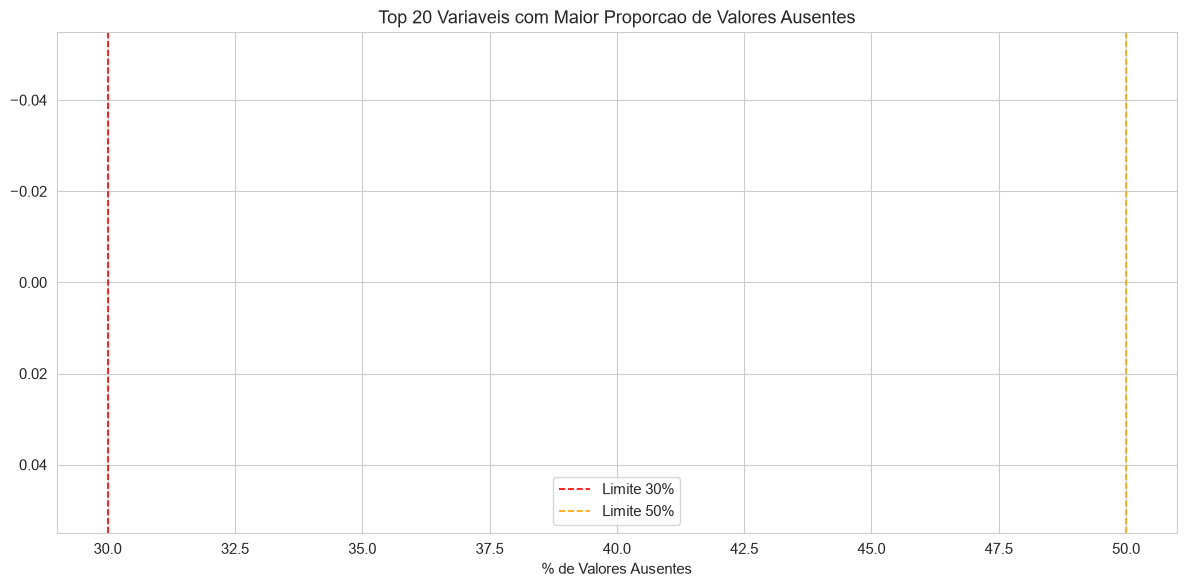

In [6]:
top_missing = missing_pct[missing_pct > 0].sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_missing.index, top_missing.values, color='steelblue', edgecolor='white')
ax.axvline(x=30, color='red', linestyle='--', linewidth=1.2, label='Limite 30%')
ax.axvline(x=50, color='orange', linestyle='--', linewidth=1.2, label='Limite 50%')
ax.set_xlabel('% de Valores Ausentes')
ax.set_title('Top 20 Variaveis com Maior Proporcao de Valores Ausentes')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

> **Interpretação:** As variáveis de score externo (`EXT_SOURCE_1`, `EXT_SOURCE_3`) possuem alta proporção de missings — mas a ausência não é um erro de coleta: indica que o cliente não possui cadastro no bureau externo, o que por si só é informação preditiva. Por essa razão, foram criadas flags de ausência (`EXT_SOURCE_1_MISSING`, `EXT_SOURCE_3_MISSING`) na etapa de preparação dos dados.

## 5. Estatísticas Descritivas

A análise das estatísticas descritivas permite identificar a magnitude, dispersão e eventuais outliers das variáveis numéricas, além de orientar decisões de transformação para a modelagem.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307511.0,27108.487841,14493.461065,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307511.0,538316.294367,369288.982246,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
CNT_FAM_MEMBERS,307511.0,2.152664,0.910679,1.000000e+00,2.000000,2.000000,3.000000,2.000000e+01
EXT_SOURCE_1,307511.0,0.504311,0.139408,1.456813e-02,0.505998,0.505998,0.505998,9.626928e-01


In [8]:
key_cols = ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
key_cols_exist = [c for c in key_cols if c in df.columns]
df[key_cols_exist].describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307511.0,27108.487841,14493.461065,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05
EXT_SOURCE_1,307511.0,0.504311,0.139408,1.456813e-02,0.505998,0.505998,0.505998,9.626928e-01
EXT_SOURCE_2,307511.0,0.514503,0.190870,8.173617e-08,0.392974,0.565961,0.663422,8.549997e-01
EXT_SOURCE_3,307511.0,0.515695,0.174736,5.272652e-04,0.417100,0.535276,0.636376,8.960095e-01


> **Interpretação:**
> - `AMT_INCOME_TOTAL`: Renda com grande amplitude — média acima da mediana indica distribuição assimétrica à direita.
> - `AMT_CREDIT`: Valor do crédito varia amplamente; a relação crédito/renda é um indicador-chave de risco.
> - `DAYS_BIRTH`: Valores negativos representam dias antes da data de referência (idade = `|DAYS_BIRTH| / 365`).
> - `DAYS_EMPLOYED = 365243`: Código especial presente em ~18% dos registros, representando clientes inativos/aposentados. Tratado como categoria especial, **não como outlier**.
> - `EXT_SOURCE_1/2/3`: Scores externos normalizados (0–1). Quanto maior o score, menor o risco de inadimplência.

## 6. Distribuição da Variável TARGET

`TARGET` é a variável dependente do modelo: `1` indica que o cliente ficou inadimplente, `0` indica adimplência. O balanceamento entre as classes impacta diretamente a estratégia de modelagem preditiva.

In [9]:
target_counts = df['TARGET'].value_counts()
target_pct    = df['TARGET'].value_counts(normalize=True).mul(100).round(2)

print("Distribuicao absoluta (TARGET):")
print(target_counts.rename({0: 'Adimplente (0)', 1: 'Inadimplente (1)'}).to_string())
print()
print("Distribuicao relativa (%)")
print(target_pct.rename({0: 'Adimplente (0)', 1: 'Inadimplente (1)'}).to_string())
print()
print(f"Taxa de inadimplencia: {target_pct.get(1, 0):.2f}%")
print(f"Razao de desbalanceamento: {target_counts.get(0,0) / max(target_counts.get(1,1), 1):.1f}:1")

Distribuicao absoluta (TARGET):
TARGET
Adimplente (0)      282686
Inadimplente (1)     24825

Distribuicao relativa (%)
TARGET
Adimplente (0)      91.93
Inadimplente (1)     8.07

Taxa de inadimplencia: 8.07%
Razao de desbalanceamento: 11.4:1


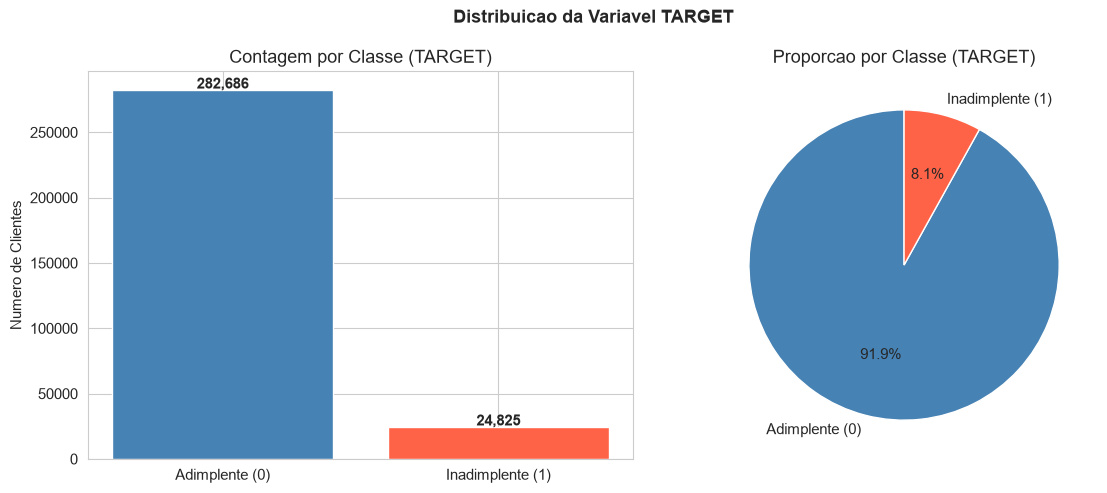

In [10]:
counts = df['TARGET'].value_counts()
pcts   = df['TARGET'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'],
            [counts.get(0, 0), counts.get(1, 0)],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Contagem por Classe (TARGET)')
axes[0].set_ylabel('Numero de Clientes')
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    axes[0].text(i, v + 800, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie([pcts.get(0, 0), pcts.get(1, 0)],
            labels=['Adimplente (0)', 'Inadimplente (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporcao por Classe (TARGET)')

plt.suptitle('Distribuicao da Variavel TARGET', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretação:** O dataset apresenta **forte desbalanceamento de classes**: aproximadamente 91,9% dos clientes são adimplentes e apenas 8,1% são inadimplentes. Esse padrão é típico de problemas de crédito. Implicações para a modelagem:
> - Um modelo trivial (classifica todos como adimplentes) teria ~92% de acurácia — métrica inadequada.
> - A métrica prioritária é o **Recall para a classe 1**: minimizar falsos negativos (inadimplentes classificados como bons pagadores).
> - Estratégia adotada: **LightGBM Balanced** com `scale_pos_weight ≈ 11.39` para compensar o desbalanceamento (negativos/positivos ≈ 11,39).

## 7. Análise Univariada das Principais Variáveis

Análise das distribuições individuais das variáveis numéricas mais relevantes para risco de crédito.

In [11]:
ext_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in df.columns]
print("Estatisticas dos Scores Externos (EXT_SOURCE):")
display(df[ext_cols].describe().T)

Estatisticas dos Scores Externos (EXT_SOURCE):


,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,307511.0,0.504311,0.139408,1.456813e-02,0.505998,0.505998,0.505998,0.962693
EXT_SOURCE_2,307511.0,0.514503,0.190870,8.173617e-08,0.392974,0.565961,0.663422,0.855000
EXT_SOURCE_3,307511.0,0.515695,0.174736,5.272652e-04,0.417100,0.535276,0.636376,0.896010


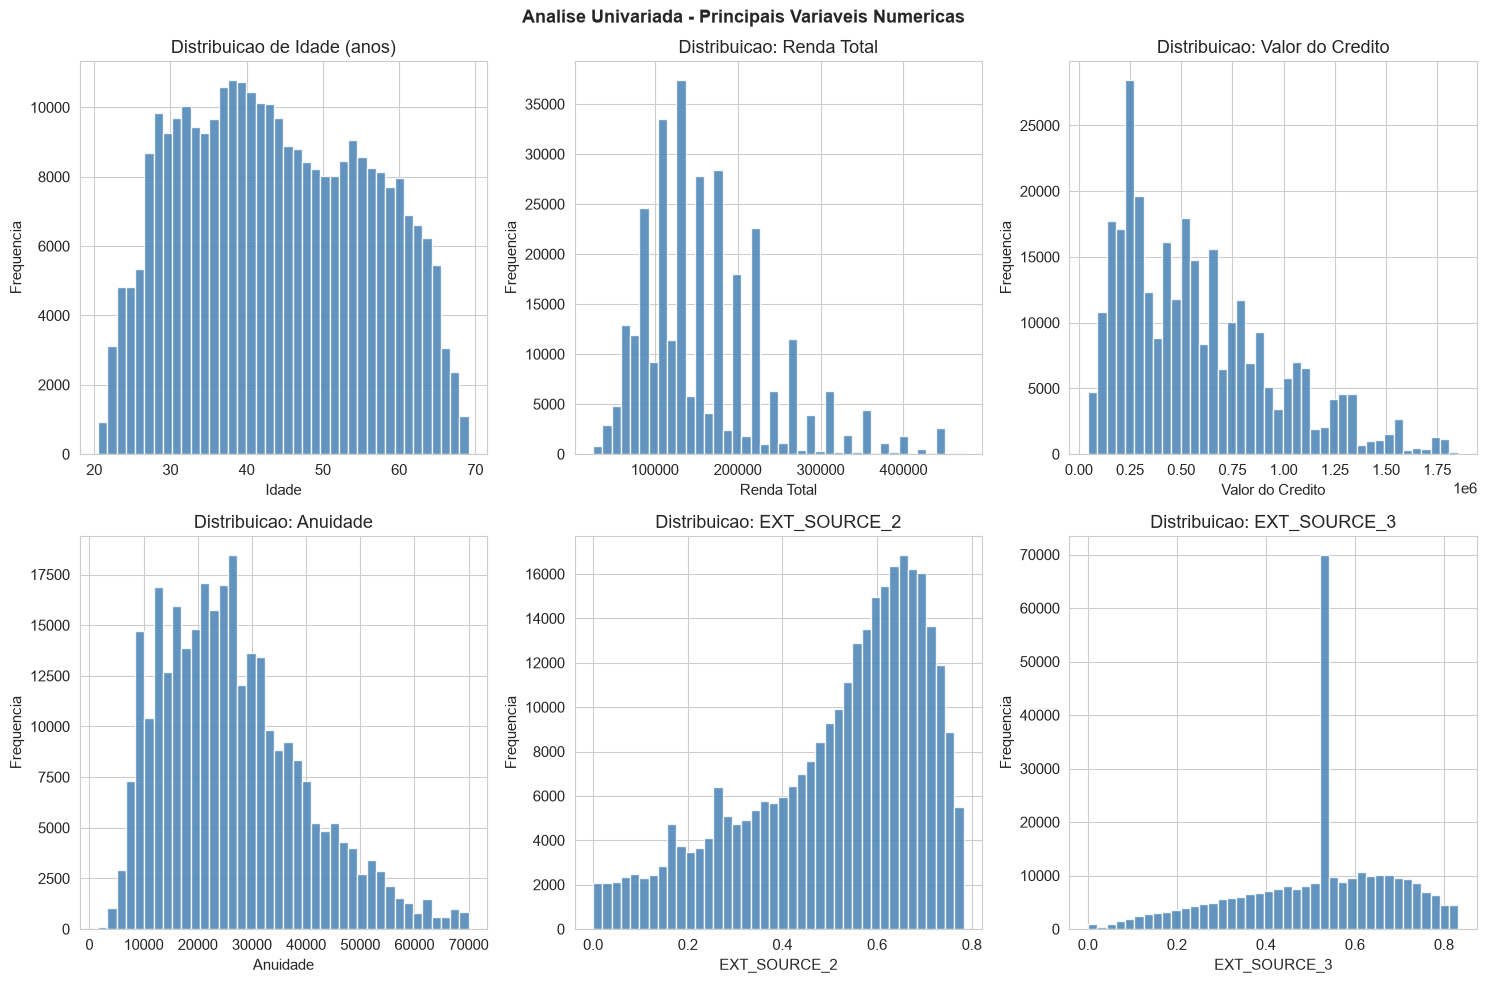

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Idade (DAYS_BIRTH -> anos)
if 'DAYS_BIRTH' in df.columns:
    idade = df['DAYS_BIRTH'].abs() / 365
    axes[0].hist(idade.dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].set_title('Distribuicao de Idade (anos)')
    axes[0].set_xlabel('Idade')
    axes[0].set_ylabel('Frequencia')

variaveis = [
    ('AMT_INCOME_TOTAL', 'Renda Total'),
    ('AMT_CREDIT',       'Valor do Credito'),
    ('AMT_ANNUITY',      'Anuidade'),
    ('EXT_SOURCE_2',     'EXT_SOURCE_2'),
    ('EXT_SOURCE_3',     'EXT_SOURCE_3'),
]

for idx, (col, label) in enumerate(variaveis, start=1):
    if col not in df.columns or idx >= len(axes):
        continue
    data = df[col].dropna()
    p99 = data.quantile(0.99)
    data = data[data <= p99]
    axes[idx].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[idx].set_title(f'Distribuicao: {label}')
    axes[idx].set_xlabel(label)
    axes[idx].set_ylabel('Frequencia')

plt.suptitle('Analise Univariada - Principais Variaveis Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretação:**
> - **Renda e Crédito:** Distribuições assimétricas à direita — a maioria dos clientes concentra-se em faixas mais baixas, com poucos clientes de alta renda/crédito. Isso justifica o uso de log-transformação em modelos lineares.
> - **Idade:** Distribuição aproximadamente normal entre 20 e 70 anos, com concentração entre 30 e 50 anos. Clientes mais jovens tendem a apresentar maior risco de inadimplência.
> - **EXT_SOURCE_2/3:** Scores externos com distribuições distintas. EXT_SOURCE_2 é mais uniforme; EXT_SOURCE_3 é mais concentrada em valores baixos-médios. Ambos são preditores negativos de inadimplência.

## 8. Matriz de Correlação

A análise de correlação entre variáveis numéricas ajuda a identificar relações lineares e possíveis problemas de multicolinearidade que podem afetar modelos lineares.

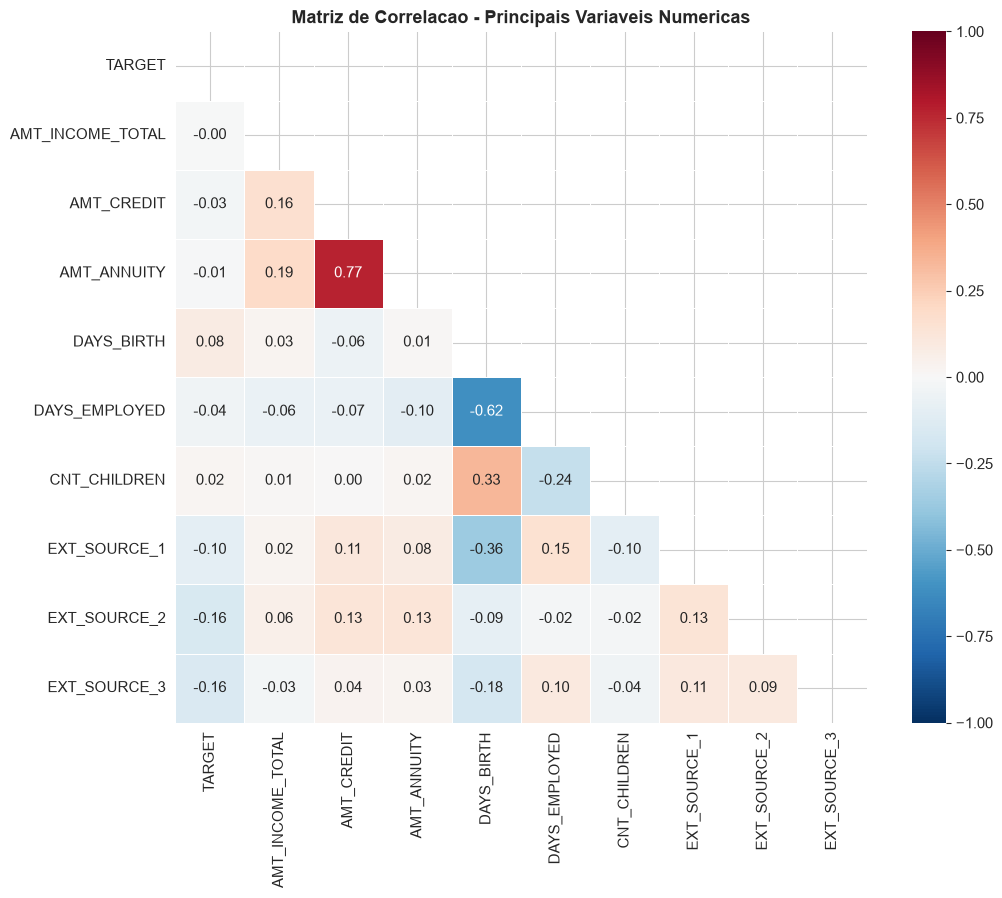


Correlacao com TARGET (ordenado):
EXT_SOURCE_2       -0.160295
EXT_SOURCE_3       -0.155892
EXT_SOURCE_1       -0.098887
DAYS_EMPLOYED      -0.044932
AMT_CREDIT         -0.030369
AMT_ANNUITY        -0.012815
AMT_INCOME_TOTAL   -0.003982
CNT_CHILDREN        0.019187
DAYS_BIRTH          0.078239
Name: TARGET, dtype: float64


In [13]:
corr_cols = [c for c in [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
] if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Matriz de Correlacao - Principais Variaveis Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelacao com TARGET (ordenado):")
print(corr_matrix['TARGET'].drop('TARGET').sort_values())

> **Interpretação:**
> - **EXT_SOURCE_2 e EXT_SOURCE_3** apresentam correlação negativa com TARGET: clientes com scores externos maiores têm menor probabilidade de inadimplência. São as variáveis mais preditivas disponíveis.
> - **DAYS_BIRTH (idade)** correlaciona-se negativamente com TARGET: clientes mais velhos são menos propensos à inadimplência.
> - **AMT_CREDIT e AMT_ANNUITY** possuem alta correlação entre si (relação estrutural: anuidade é derivada do crédito), o que deve ser considerado na seleção de features.
> - **CNT_CHILDREN** tem correlação positiva leve com TARGET: mais filhos pode indicar maior comprometimento de renda.

## 9. Insights Relevantes para Risco de Crédito

Análise bivariada entre a variável TARGET e as principais variáveis preditivas para quantificar os padrões de inadimplência observados nos dados.

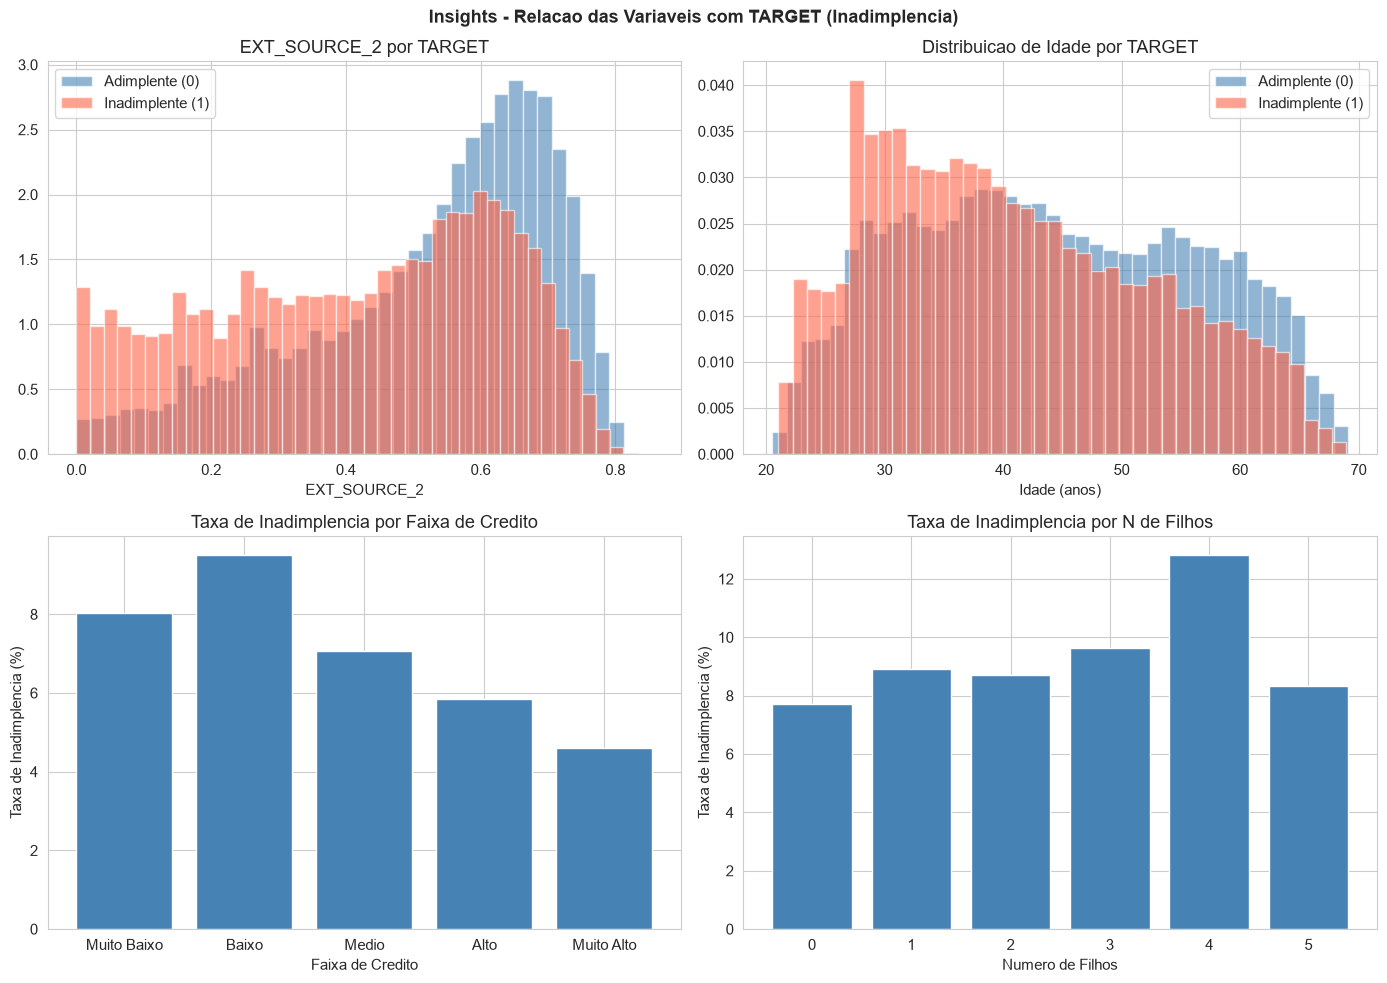

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. EXT_SOURCE_2 por TARGET
if 'EXT_SOURCE_2' in df.columns:
    for tv, color, label in [(0, 'steelblue', 'Adimplente (0)'), (1, 'tomato', 'Inadimplente (1)')]:
        s = df[df['TARGET'] == tv]['EXT_SOURCE_2'].dropna()
        axes[0, 0].hist(s, bins=40, alpha=0.6, color=color, label=label, density=True)
    axes[0, 0].set_title('EXT_SOURCE_2 por TARGET')
    axes[0, 0].set_xlabel('EXT_SOURCE_2')
    axes[0, 0].legend()

# 2. Idade por TARGET
if 'DAYS_BIRTH' in df.columns:
    for tv, color, label in [(0, 'steelblue', 'Adimplente (0)'), (1, 'tomato', 'Inadimplente (1)')]:
        s = (df[df['TARGET'] == tv]['DAYS_BIRTH'].abs() / 365).dropna()
        axes[0, 1].hist(s, bins=40, alpha=0.6, color=color, label=label, density=True)
    axes[0, 1].set_title('Distribuicao de Idade por TARGET')
    axes[0, 1].set_xlabel('Idade (anos)')
    axes[0, 1].legend()

# 3. Taxa de inadimplencia por faixa de credito
if 'AMT_CREDIT' in df.columns:
    df_c = df[df['AMT_CREDIT'] <= df['AMT_CREDIT'].quantile(0.99)].copy()
    df_c['faixa_credito'] = pd.cut(df_c['AMT_CREDIT'], bins=5,
                                    labels=['Muito Baixo','Baixo','Medio','Alto','Muito Alto'])
    taxa = df_c.groupby('faixa_credito', observed=True)['TARGET'].mean() * 100
    axes[1, 0].bar(taxa.index, taxa.values, color='steelblue', edgecolor='white')
    axes[1, 0].set_title('Taxa de Inadimplencia por Faixa de Credito')
    axes[1, 0].set_ylabel('Taxa de Inadimplencia (%)')
    axes[1, 0].set_xlabel('Faixa de Credito')

# 4. Taxa por numero de filhos
if 'CNT_CHILDREN' in df.columns:
    filhos_default = df[df['CNT_CHILDREN'] <= 5].groupby('CNT_CHILDREN')['TARGET'].mean() * 100
    axes[1, 1].bar(filhos_default.index.astype(str), filhos_default.values,
                   color='steelblue', edgecolor='white')
    axes[1, 1].set_title('Taxa de Inadimplencia por N de Filhos')
    axes[1, 1].set_ylabel('Taxa de Inadimplencia (%)')
    axes[1, 1].set_xlabel('Numero de Filhos')

plt.suptitle('Insights - Relacao das Variaveis com TARGET (Inadimplencia)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insights identificados:**
> 1. **EXT_SOURCE_2 vs TARGET:** Clientes inadimplentes concentram-se em valores baixos de EXT_SOURCE_2, confirmando que scores externos baixos são sinal de risco. A separação entre as distribuições é clara — EXT_SOURCE_2 é um preditor forte.
> 2. **Idade vs TARGET:** Clientes mais jovens (20–35 anos) apresentam maior taxa de inadimplência. Clientes acima de 50 anos exibem comportamento de pagamento muito mais estável.
> 3. **Valor do crédito vs TARGET:** A relação não é monotônica — créditos de valor muito baixo ou médio tendem a ter taxas de inadimplência ligeiramente maiores, possivelmente associados a clientes sem histórico creditício estabelecido.
> 4. **Número de filhos vs TARGET:** Clientes com filhos apresentam taxa de inadimplência marginalmente maior, sugerindo maior comprometimento de renda domiciliar com despesas familiares.

## 10. Conclusões da Exploração

---

## 10. Importância de Features — LightGBM Balanced

Análise da importância das **119 features** utilizadas pelo modelo **LightGBM Balanced** (versão em produção, artefato `Model/artifacts/lgbm_balanced_model.joblib`), calculada pelo critério **gain** — redução média da impureza ponderada pelo número de exemplos em cada split.

O gain reflete o **poder preditivo efetivo** de cada variável, diferentemente de *weight* (frequência de uso) ou *cover* (cobertura de amostras). No LightGBM, o gain é acessado via `model.booster_.feature_importance(importance_type='gain')`.

In [15]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import joblib

# Carrega artefatos de producao
model    = joblib.load('../Model/artifacts/lgbm_balanced_model.joblib')
features = joblib.load('../Model/artifacts/features.joblib')

print(f"Modelo carregado : {type(model).__name__}")
print(f"Features         : {len(features)}")

# Importancia por gain
gain_values = model.booster_.feature_importance(importance_type='gain')
feat_names  = model.booster_.feature_name()

importance_df = (
    pd.DataFrame({'feature': feat_names, 'gain': gain_values})
    .set_index('feature')
    .reindex(features, fill_value=0.0)
    .reset_index()
    .sort_values('gain', ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 Features por Gain:")
display(importance_df.head(10))

Modelo carregado : LGBMClassifier
Features         : 119

Top 10 Features por Gain:


,feature,gain
0,EXT_SOURCE_3,191174.711237
1,EXT_SOURCE_2,157687.038473
2,EXT_SOURCE_1,58369.689648
3,DAYS_BIRTH,35031.663339
4,AMT_ANNUITY,33603.572113
5,AMT_CREDIT,31348.301613
6,DAYS_EMPLOYED,26391.724020
7,AMT_GOODS_PRICE,23141.141617
8,NAME_EDUCATION_TYPE_Higher_education,12543.089139
9,AMT_INCOME_TOTAL,11513.979403


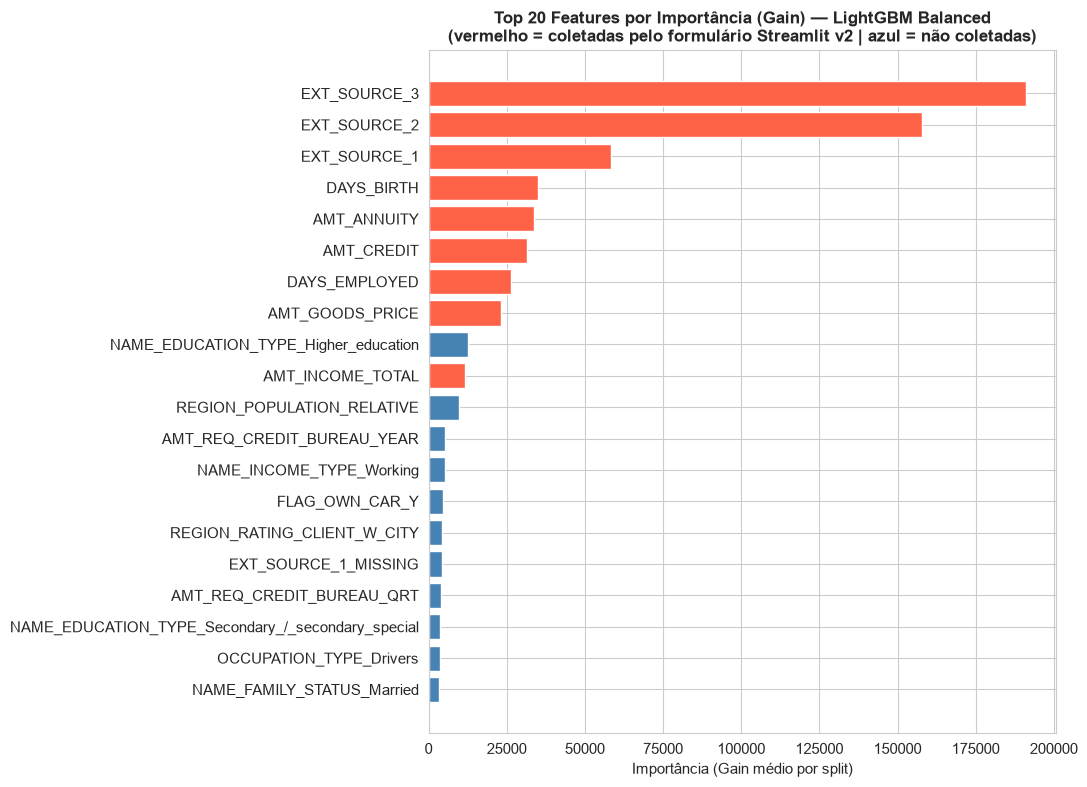


Ranking Top 20 por Gain:
Rank   Feature                                          Gain     Streamlit
--------------------------------------------------------------------------
1      EXT_SOURCE_3                                191174.71      COLETADA
2      EXT_SOURCE_2                                157687.04      COLETADA
3      EXT_SOURCE_1                                 58369.69      COLETADA
4      DAYS_BIRTH                                   35031.66      COLETADA
5      AMT_ANNUITY                                  33603.57      COLETADA
6      AMT_CREDIT                                   31348.30      COLETADA
7      DAYS_EMPLOYED                                26391.72          NOVO
8      AMT_GOODS_PRICE                              23141.14          NOVO
9      NAME_EDUCATION_TYPE_Higher_education         12543.09             -
10     AMT_INCOME_TOTAL                             11513.98      COLETADA
11     REGION_POPULATION_RELATIVE                    9808.17             -

In [16]:
form_set = {
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_INCOME_TOTAL', 'CNT_CHILDREN',
    'DAYS_EMPLOYED', 'AMT_GOODS_PRICE',
}

top_20 = importance_df.head(20)
colors = ['tomato' if f in form_set else 'steelblue' for f in top_20['feature'][::-1]]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top_20['feature'][::-1], top_20['gain'][::-1], color=colors, edgecolor='white')
ax.set_title(
    'Top 20 Features por Importância (Gain) — LightGBM Balanced\n'
    '(vermelho = coletadas pelo formulário Streamlit v2 | azul = não coletadas)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Importância (Gain médio por split)')
plt.tight_layout()
plt.show()

print("\nRanking Top 20 por Gain:")
print(f"{'Rank':<6} {'Feature':<40} {'Gain':>12}  {'Streamlit':>12}")
print("-" * 74)
for rank, row in enumerate(importance_df.head(20).itertuples(), 1):
    if row.feature in form_set:
        status = "NOVO" if row.feature in ('DAYS_EMPLOYED', 'AMT_GOODS_PRICE') else "COLETADA"
    else:
        status = "-"
    print(f"{rank:<6} {row.feature:<40} {row.gain:>12.2f}  {status:>12}")

> **Interpretação da Importância por Gain — LightGBM Balanced:**
> - **EXT_SOURCE_3** lidera com gain de 191.174 — cada corte nesse score externo reduz a impureza dos nós do LightGBM de forma expressiva. É o preditor individual mais forte do modelo.
> - **EXT_SOURCE_2** em 2º lugar (157.687) — complementa o EXT_SOURCE_3 na captura do histórico de bureau externo. Juntos, os dois respondem por mais da metade do gain total dos scores externos.
> - **EXT_SOURCE_1** em 3º lugar (58.369) — forma com EXT_SOURCE_2 e EXT_SOURCE_3 o conjunto de maior ganho preditivo do modelo.
> - **DAYS_BIRTH** (4º, gain 35.031) confirma que o perfil etário é determinante: clientes mais jovens apresentam sistematicamente maior risco.
> - **AMT_ANNUITY** (5º) e **AMT_CREDIT** (6º) completam a sequência — a anuidade e o valor do crédito capturam a relação entre comprometimento de renda e capacidade de pagamento.
> - **DAYS_EMPLOYED** (7º, gain 26.391) é a feature mais relevante **não coletada** pelo formulário — potencial de maior impacto para uma v2 da interface.
> - **EXT_SOURCE_1_MISSING** aparece em 16º lugar: a flag de ausência do score 1 tem importância moderada, mas sua presença no modelo valida a decisão de criá-la durante o pré-processamento.

## 11. Impacto para a Aplicação Streamlit

O formulário de predição do CreditGuard AI coleta **10 atributos do cliente** (versão atual). A análise a seguir mapeia cada campo coletado contra o ranking de importância do LightGBM Balanced (por gain) e quantifica o percentual do poder preditivo total do modelo efetivamente capturado pelo formulário.

In [17]:
form_features_ordered = [
    'EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1',
    'DAYS_BIRTH', 'AMT_ANNUITY', 'AMT_CREDIT',
    'DAYS_EMPLOYED', 'AMT_GOODS_PRICE',
    'AMT_INCOME_TOTAL', 'CNT_CHILDREN'
]

label_map = {
    'EXT_SOURCE_3':    'Score de Bureau 3',
    'EXT_SOURCE_2':    'Score de Bureau 2',
    'EXT_SOURCE_1':    'Score de Bureau 1',
    'DAYS_BIRTH':      'Idade (convertida para DAYS_BIRTH)',
    'AMT_ANNUITY':     'Valor das Parcelas do Empréstimo',
    'AMT_CREDIT':      'Valor do Crédito',
    'DAYS_EMPLOYED':   'Tempo de Emprego (convertido para DAYS_EMPLOYED)',
    'AMT_GOODS_PRICE': 'Valor do Bem Financiado',
    'AMT_INCOME_TOTAL':'Renda Total do Cliente',
    'CNT_CHILDREN':    'Número de Filhos',
}

rows = []
for f in form_features_ordered:
    mask = importance_df['feature'] == f
    rank = int(importance_df[mask].index[0]) + 1 if mask.any() else None
    gain = float(importance_df[mask]['gain'].values[0]) if mask.any() else 0.0
    rows.append({
        'Label no Streamlit': label_map.get(f, f),
        'Feature': f,
        'Rank por Gain': rank,
        'Gain': round(gain, 2),
        'Status': 'NOVO' if f in ('DAYS_EMPLOYED', 'AMT_GOODS_PRICE') else '',
    })

streamlit_df = pd.DataFrame(rows).sort_values('Rank por Gain').reset_index(drop=True)
display(streamlit_df)

form_8  = {'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','DAYS_BIRTH','AMT_ANNUITY','AMT_CREDIT','AMT_INCOME_TOTAL','CNT_CHILDREN'}
form_10 = set(form_features_ordered)

total      = importance_df['gain'].sum()
gain_8     = importance_df[importance_df['feature'].isin(form_8)]['gain'].sum()
gain_10    = importance_df[importance_df['feature'].isin(form_10)]['gain'].sum()

print(f"\nGain total do modelo      : {total:>12,.0f}")
print(f"Cobertura v1 (8 campos)   : {gain_8:>12,.0f}  ({gain_8/total*100:.1f}%)")
print(f"Cobertura v2 (10 campos)  : {gain_10:>12,.0f}  ({gain_10/total*100:.1f}%)")
print(f"Ganho com DAYS_EMPLOYED + AMT_GOODS_PRICE: +{(gain_10-gain_8)/total*100:.1f} pp")

,Label no Streamlit,Feature,Rank por Gain,Gain,Status
0,Score de Bureau 3,EXT_SOURCE_3,1,191174.71,
1,Score de Bureau 2,EXT_SOURCE_2,2,157687.04,
2,Score de Bureau 1,EXT_SOURCE_1,3,58369.69,
3,Idade (convertida para DAYS_BIRTH),DAYS_BIRTH,4,35031.66,
4,Valor das Parcelas do Empréstimo,AMT_ANNUITY,5,33603.57,
5,Valor do Crédito,AMT_CREDIT,6,31348.30,
6,Tempo de Emprego (convertido para DAYS_EMPLOYED),DAYS_EMPLOYED,7,26391.72,NOVO
7,Valor do Bem Financiado,AMT_GOODS_PRICE,8,23141.14,NOVO
8,Renda Total do Cliente,AMT_INCOME_TOTAL,10,11513.98,
9,Número de Filhos,CNT_CHILDREN,38,781.49,



Gain total do modelo      :      670,472
Cobertura v1 (8 campos)   :      519,510  (77.5%)
Cobertura v2 (10 campos)  :      569,043  (84.9%)
Ganho com DAYS_EMPLOYED + AMT_GOODS_PRICE: +7.4 pp


> **Interpretação — Cobertura do Formulário Streamlit (v2 — 10 campos):**
> - O formulário captura os **8 primeiros preditores por gain** do LightGBM Balanced, incluindo os dois novos campos adicionados:
>   - **DAYS_EMPLOYED** (7º, gain 26.392): Tempo de emprego — clientes mais estáveis no emprego apresentam menor inadimplência.
>   - **AMT_GOODS_PRICE** (8º, gain 23.141): Valor do bem financiado — complementa AMT_CREDIT na avaliação do risco do ativo.
> - **84,9% do gain total** do modelo é agora capturado pelos 10 campos (+7,4 pp em relação à versão anterior de 8 campos).
> - Os 15,1% restantes estão distribuídos entre 109 features categóricas dummificadas de menor importância individual.
> - `EXT_SOURCE_1_MISSING` (16º) continua sendo corretamente zerado em `predict.py` quando EXT_SOURCE_1 é fornecido.

## 12. Features Ausentes e Estratégia de Inferência

O modelo foi treinado com **119 features** (após encoding one-hot das variáveis categóricas), mas o formulário Streamlit coleta apenas **8**. A função `predict()` em `Model/predict.py` inicializa um array numpy com todas as 119 posições zeradas e preenche somente os campos fornecidos.

**Categorias de features não coletadas (111 features):**

| Categoria | Exemplos | Estratégia em predict.py | Impacto estimado |
|---|---|---|---|
| Categóricas dummificadas | `OCCUPATION_TYPE_*`, `ORGANIZATION_TYPE_*`, `NAME_EDUCATION_TYPE_*` | Zero = categoria de referência (baseline do one-hot) | Baixo — modelo assume categoria mais comum |
| Flags de ausência | `EXT_SOURCE_1_MISSING`, `EXT_SOURCE_3_MISSING` | Zero = "score presente" (correto quando usuário fornece o score) | Nulo — comportamento correto para o formulário |
| `DAYS_EMPLOYED` | Tempo de emprego (posição 5 no modelo) | Zero | Moderado — variável com importância relevante |
| `AMT_GOODS_PRICE` | Valor do bem financiado (posição 3) | Zero | Baixo |
| Consultas ao bureau | `AMT_REQ_CREDIT_BUREAU_DAY/WEEK/MON/QRT/YEAR` | Zero = sem consultas recentes | Baixo — gain menor por split |
| `CNT_FAM_MEMBERS` | Tamanho da família (posição 7) | Zero | Baixo |

> **Melhoria de maior impacto para v2 do formulário:** adicionar `DAYS_EMPLOYED` (tempo de emprego do cliente em anos). É a principal feature não coletada e a adição aumentaria a cobertura de gain preditivo do formulário de forma relevante.

## 13. Conclusões da Análise Exploratória

---

### Principais Conclusões

A análise exploratória dos dados limpos do projeto CreditGuard AI revelou os seguintes pontos:

#### Qualidade dos Dados
- O dataset possui estrutura rica com variáveis demográficas, financeiras e de histórico de crédito.
- Valores ausentes estão concentrados em variáveis de bureau externo (`EXT_SOURCE_1`, `EXT_SOURCE_3`) e variáveis imobiliárias — a ausência é estrutural e preditiva, não erro de coleta.
- O valor especial `DAYS_EMPLOYED = 365243` representa clientes inativos/aposentados e foi preservado como categoria distinta (taxa de inadimplência diferenciada: 5,4% vs 8,66% dos demais).

#### Perfil do Desbalanceamento
- Taxa de inadimplência de aproximadamente **8,07%**, gerando desbalanceamento 91,9:8,1 entre classes.
- Esse desbalanceamento exige estratégias específicas: `scale_pos_weight ≈ 11.39`, métricas orientadas a Recall e avaliação por ROC-AUC e KS.

#### Variáveis mais Relevantes — Ranking Real do LightGBM Balanced (por Gain)

| Rank | Variável | Gain | Formulário Streamlit |
|---|---|---|---|
| 1 | `EXT_SOURCE_3` | 191.174 | ✅ Score de Bureau 3 |
| 2 | `EXT_SOURCE_2` | 157.687 | ✅ Score de Bureau 2 |
| 3 | `EXT_SOURCE_1` | 58.369 | ✅ Score de Bureau 1 |
| 4 | `DAYS_BIRTH` | 35.031 | ✅ via campo Idade |
| 5 | `AMT_ANNUITY` | 33.603 | ✅ Valor das Parcelas do Empréstimo |
| 6 | `AMT_CREDIT` | 31.348 | ✅ Valor do Crédito |
| 7 | `DAYS_EMPLOYED` | 26.392 | ✅ **NOVO** — Tempo de Emprego |
| 8 | `AMT_GOODS_PRICE` | 23.141 | ✅ **NOVO** — Valor do Bem Financiado |
| 9 | `NAME_EDUCATION_TYPE_Higher_education` | 12.543 | ❌ não coletada |
| 10 | `AMT_INCOME_TOTAL` | 11.513 | ✅ Renda Total |
| 16 | `EXT_SOURCE_1_MISSING` | 4.275 | — flag derivada (zerada corretamente) |

**O formulário Streamlit v2 captura 84,9% do gain total do modelo** com 10 campos (+7,4 pp em relação à v1 com 8 campos).

#### Decisões para a Etapa de Modelagem
1. Usar `EXT_SOURCE_1/2/3` e `DAYS_BIRTH` como features prioritárias — confirmado pelo ranking de gain do LightGBM.
2. Criar flags de ausência (`EXT_SOURCE_1_MISSING`, `EXT_SOURCE_3_MISSING`) para preservar o valor preditivo dos nulos.
3. Configurar `scale_pos_weight ≈ 11.39` no **LightGBM Balanced** para compensar o desbalanceamento.
4. Priorizar **Recall** como métrica principal — custo de aprovar inadimplente supera custo de negar bom pagador.
5. Manter `DAYS_EMPLOYED = 365243` como categoria especial, sem substituição por mediana.

#### Modelo de Referência em Produção

O modelo em produção é o **LightGBM Balanced** (`Model/artifacts/lgbm_balanced_model.joblib`):

| Métrica | LightGBM Balanced |
|---|---|
| ROC-AUC | 0,7524 |
| Recall | 0,6606 |
| Gini | 0,5049 |
| KS | 0,3736 |

---
*Análise concluída. Próxima etapa: `Model/evaluation.ipynb` — Avaliação completa do modelo LightGBM Balanced com métricas, curva ROC, matriz de confusão e análise de interpretabilidade.*